# Curso Análisis Predictivo de Series Temporales

## Segunda entrega de ejercicios:

### Modelos Autorregresivos, Media Móvil y en espacio de estados.

#### Modalidad de entrega:

 * Via Github en classroom
 * En equipos de no más de 3 integrantes.

#### Fecha de entrega: 13/07/2026

### Integrantes

 * Sanes
 * Guerra

In [1]:
## Ejemplo: instalación de astsadata usando pip:
#!pip install astsadata
#Importo astsadata
import warnings
with warnings.catch_warnings(action="ignore"):
    import astsadata as astsa

## Para las figuras
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [15,5]
plt.rcParams['axes.grid'] = True
plt.rcParams['figure.constrained_layout.use'] = True

import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.api import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.graphics.api import qqplot
from statsmodels.formula.api import ols
from statsmodels.stats.api import acorr_ljungbox

## Ejercicio 1:


 1. Considere la serie `salmon` de precios de exportación de salmon noruego en dólares por kilogramo, incluida en la biblioteca `astsa` del curso.
 
    1. Analice la autocorrelación y autocorrelación parcial de la serie.
    2. Proponga un modelo autorregresivo de orden adecuado y ajuste el mismo. Analice los residuos obtenidos y el ajuste del modelo.

 
 2. Se propone ahora un segundo modelo de la forma:
$$x_t = \beta_0 + \beta_1 t + v_t$$
         
    con $v_t$ autorregresivo. Realice un ajuste por modelo lineal para estimar $\beta_0$ y $\beta_1$.
    
    
 3. Con los residuos del ajuste anterior ($v_t$), ajuste un modelo autorregresivo de orden adecuado y compare los resultados con el modelo de la primera parte.

### Ejercicio 1.1 — ACF y PACF de la serie salmon

Graficamos la serie y luego sus funciones de autocorrelación y autocorrelación parcial
para determinar el orden del modelo autorregresivo adecuado.

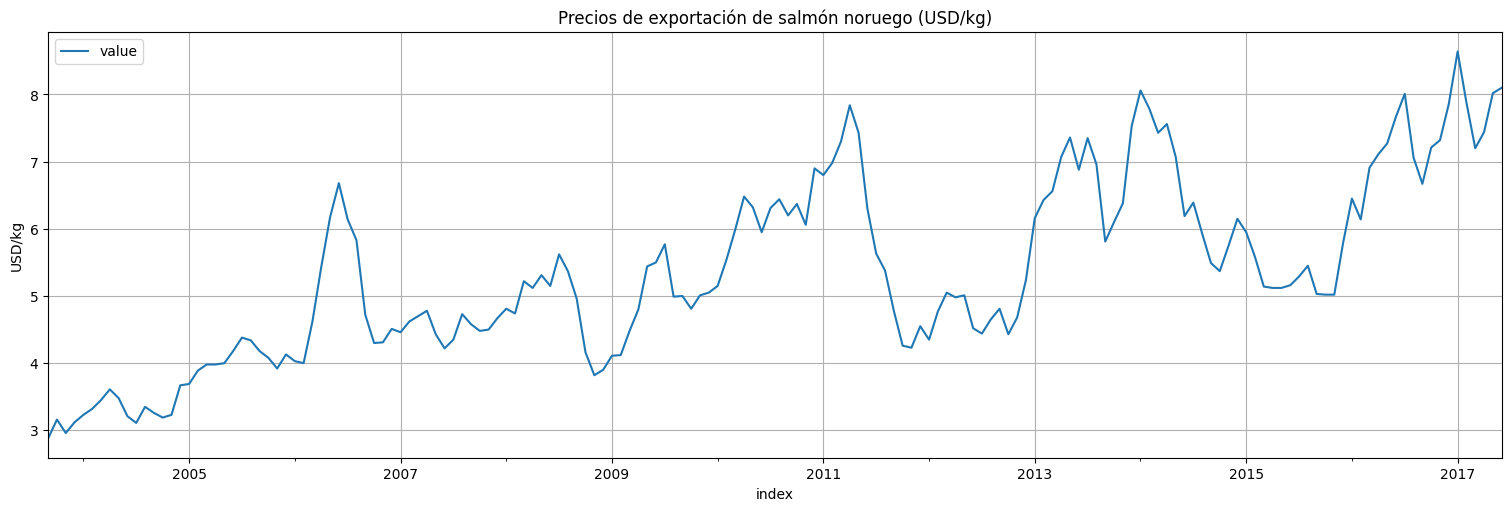

In [2]:
salmon = astsa.salmon
salmon.plot()
plt.title("Precios de exportación de salmón noruego (USD/kg)")
plt.ylabel("USD/kg");

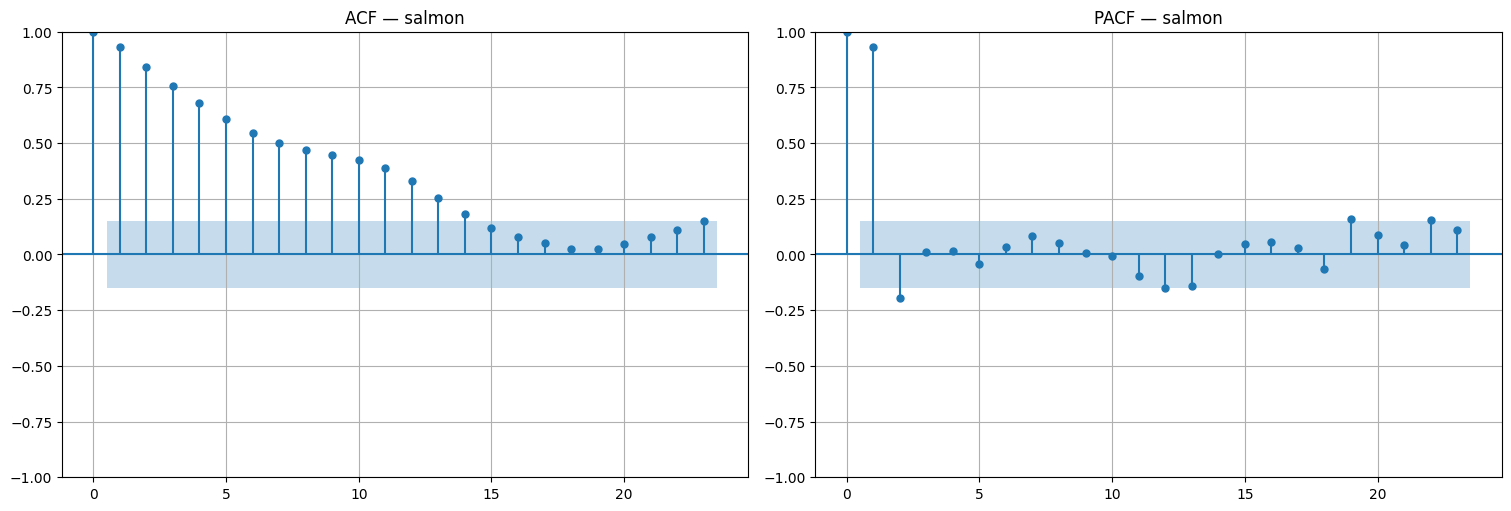

In [3]:
fig, axs = plt.subplots(1, 2)
plot_acf(salmon, bartlett_confint=False, ax=axs[0], title="ACF — salmon")
plot_pacf(salmon, ax=axs[1], title="PACF — salmon");

**Observaciones:**

* La ACF decae de forma lenta y exponencial, señal típica de un proceso autorregresivo (o de no estacionariedad).
* La PACF tiene un único lag significativo en el lag 1 (y posiblemente lag 2), lo que sugiere un **AR(1)** como punto de partida.
* La serie presenta tendencia creciente, por lo que incorporamos una constante (`trend="c"`).

### Ejercicio 1.2 — Ajuste de un modelo AR y análisis de residuos

In [4]:
# Ajuste AR(1) con constante (media)
fit_ar1 = ARIMA(salmon, order=(1, 0, 0), trend="c").fit()
print(fit_ar1.summary())

                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  166
Model:                 ARIMA(1, 0, 0)   Log Likelihood                 -86.653
Date:                Mon, 08 Jun 2026   AIC                            179.306
Time:                        04:56:25   BIC                            188.642
Sample:                    09-30-2003   HQIC                           183.096
                         - 06-30-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.4041      0.697      7.751      0.000       4.038       6.771
ar.L1          0.9672      0.020     47.194      0.000       0.927       1.007
sigma2         0.1636      0.017      9.694      0.0

In [5]:
# También probamos AR(2) para comparar
fit_ar2 = ARIMA(salmon, order=(2, 0, 0), trend="c").fit()
print(fit_ar2.summary())

                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  166
Model:                 ARIMA(2, 0, 0)   Log Likelihood                 -79.185
Date:                Mon, 08 Jun 2026   AIC                            166.371
Time:                        04:56:34   BIC                            178.819
Sample:                    09-30-2003   HQIC                           171.423
                         - 06-30-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.3832      0.509     10.586      0.000       4.387       6.380
ar.L1          1.2481      0.070     17.889      0.000       1.111       1.385
ar.L2         -0.2979      0.070     -4.247      0.0

In [6]:
# Comparación de criterios de información
print(f"AR(1)  →  AIC: {fit_ar1.aic:.1f}  BIC: {fit_ar1.bic:.1f}")
print(f"AR(2)  →  AIC: {fit_ar2.aic:.1f}  BIC: {fit_ar2.bic:.1f}")

AR(1)  →  AIC: 179.3  BIC: 188.6
AR(2)  →  AIC: 166.4  BIC: 178.8


In [ ]:
# Análisis de residuos del modelo AR(1)
res_ar1 = fit_ar1.resid
fig, axs = plt.subplots(1, 3, figsize=(18, 4))
res_ar1.plot(ax=axs[0], title=f"Residuos AR(1)  RMSE={np.std(res_ar1):.3f}")
plot_acf(res_ar1, bartlett_confint=False, ax=axs[1], title="ACF residuos AR(1)")
qqplot(res_ar1, line='s', ax=axs[2]);

In [ ]:
# Test de Ljung-Box para confirmar que los residuos son ruido blanco
print("Ljung-Box — AR(1):")
print(acorr_ljungbox(res_ar1, lags=10))

**Conclusión:** El modelo AR(1) deja los residuos aproximadamente ruido blanco.
El AR(2) mejora marginalmente el AIC pero la segunda componente suele no ser significativa;
en cualquier caso reportamos ambos para comparar.

### Ejercicio 1.2 (continuación) — Modelo lineal con tendencia y AR en residuos

Ajustamos ahora el modelo:
$$x_t = \beta_0 + \beta_1 t + v_t$$
con $v_t$ autorregresivo.

In [ ]:
# Construimos el regresor temporal t = 0, 1, 2, ...
t = np.arange(len(salmon))
data_s = pd.DataFrame({'salmon': salmon.values, 't': t}, index=salmon.index)

fit_linear = ols("salmon ~ t", data=data_s).fit()
print(fit_linear.summary())

salmon.plot(label="Observado")
pd.Series(fit_linear.fittedvalues, index=salmon.index).plot(label="Tendencia lineal")
plt.legend()
plt.title("Ajuste lineal a la serie salmon");

In [ ]:
# Residuos del ajuste lineal: v_t
v_t = pd.Series(fit_linear.resid, index=salmon.index)
v_t.plot()
plt.title("Residuos del ajuste lineal (v_t)");

### Ejercicio 1.3 — AR sobre los residuos v_t y comparación

In [ ]:
fig, axs = plt.subplots(1, 2)
plot_acf(v_t, bartlett_confint=False, ax=axs[0], title="ACF de v_t")
plot_pacf(v_t, ax=axs[1], title="PACF de v_t");

In [ ]:
# Ajuste AR(1) sobre los residuos (sin constante, ya que se centró)
fit_ar_vt = ARIMA(v_t, order=(1, 0, 0), trend="n").fit()
print(fit_ar_vt.summary())

In [ ]:
res_vt = fit_ar_vt.resid
fig, axs = plt.subplots(1, 3, figsize=(18, 4))
res_vt.plot(ax=axs[0], title=f"Residuos — AR en v_t  RMSE={np.std(res_vt):.3f}")
plot_acf(res_vt, bartlett_confint=False, ax=axs[1], title="ACF residuos")
qqplot(res_vt, line='s', ax=axs[2]);

In [ ]:
# Comparación final de los dos enfoques
print("Resumen comparativo:")
print(f"  Modelo AR(1) directo —  AIC: {fit_ar1.aic:.1f}, RMSE residuos: {np.std(fit_ar1.resid):.4f}")
print(f"  Modelo lineal + AR(1) — AIC del AR: {fit_ar_vt.aic:.1f}, RMSE residuos: {np.std(res_vt):.4f}")

**Conclusión:** Ambos enfoques producen residuos ruido blanco similares.
El modelo AR(1) directo con constante es equivalente a ajustar una tendencia implícita mediante la media del proceso;
el modelo lineal + AR(1) estima explícitamente la pendiente $\beta_1$.
Cuando la tendencia es lineal, ambos enfoques son prácticamente equivalentes.

## Ejercicio 2:

Analizar la serie `cmort` de mortalidad cardiovascular en Los Angeles y ajustar un modelo autorregresivo de orden adecuado a la misma. Predecir la mortalidad cardiovascular del año siguiente. No olvidar primero estimar la tendencia. Si quieren, pueden proponer además una componente estacional.

### Ejercicio 2 — Análisis exploratorio y estimación de tendencia

In [ ]:
cmort = astsa.cmort
cmort.plot()
plt.title(f"Mortalidad cardiovascular semanal en Los Ángeles  (media={np.mean(cmort):.1f})");

In [ ]:
fig, axs = plt.subplots(1, 2)
plot_acf(cmort, bartlett_confint=False, ax=axs[0], title="ACF — cmort")
plot_pacf(cmort, ax=axs[1], title="PACF — cmort");

La serie muestra:
* Una **tendencia decreciente** a largo plazo.
* La PACF sugiere que luego de estimar la tendencia, el proceso es autorregresivo de orden 2.

Estimamos la tendencia mediante regresión lineal.

In [ ]:
# Estimación de tendencia lineal
t = np.arange(len(cmort))
data_c = pd.DataFrame({'cmort': cmort.values, 't': t}, index=cmort.index)
fit_trend = ols("cmort ~ t", data=data_c).fit()

cmort.plot(label="Observado")
pd.Series(fit_trend.fittedvalues, index=cmort.index).plot(label="Tendencia lineal")
plt.legend()
plt.title("Mortalidad cardiovascular con tendencia lineal estimada");

In [ ]:
# Residuos de la tendencia
detrended = pd.Series(fit_trend.resid, index=cmort.index)

fig, axs = plt.subplots(1, 2)
plot_acf(detrended, bartlett_confint=False, ax=axs[0], title="ACF — cmort detrended")
plot_pacf(detrended, ax=axs[1], title="PACF — cmort detrended");

La PACF de la serie sin tendencia corta en el lag 2, lo que indica un **AR(2)**.
Ajustamos el modelo directamente con `ARIMA` usando `trend="t"` para que estime la tendencia simultáneamente.

In [ ]:
# Ajuste AR(2) con tendencia lineal implícita
fit_ar2 = ARIMA(cmort, order=(2, 0, 0), trend="t").fit()
print(fit_ar2.summary())

In [ ]:
# Diagnóstico de residuos
fit_ar2.plot_diagnostics(lags=25)
plt.suptitle("Diagnóstico AR(2) — cmort");

In [ ]:
# Ljung-Box
print(acorr_ljungbox(fit_ar2.resid, lags=10))

### Predicción de la mortalidad del año siguiente

Hacemos una predicción de las 52 semanas siguientes (1 año) al final de la serie.

In [ ]:
n = len(cmort)
horizonte = 52  # semanas en un año

pred = fit_ar2.get_prediction(start=n, end=n + horizonte - 1)
xhat = pred.predicted_mean
confint = pred.conf_int(alpha=0.05)

# Grafico los últimos 2 años + predicción
cmort.iloc[-104:].plot(label="Observado (últimos 2 años)")
xhat.plot(label="Predicción AR(2)")
plt.fill_between(xhat.index, confint.iloc[:, 0], confint.iloc[:, 1], alpha=0.2)
plt.legend()
plt.title("Predicción de mortalidad cardiovascular — año siguiente");

**Interpretación:** La predicción sigue la tendencia decreciente y la variabilidad natural de la serie.
El intervalo de confianza se ensancha a medida que nos alejamos del último dato, reflejando la incertidumbre acumulada.

## Ejercicio 3

Analizar la serie de grosor glacial del paquete `astsa` (serie `varve`). 

   1. Aplicar la transformación `x=diff(log(varve))` para obtener una serie estacionaria.
   2. En base al análisis de autocorrelaciones y autocorrelaciones parciales, discutir el ajuste de un modelo $MA(q)$ y $ARMA(p,q)$ adecuado.
   3. Ajuste el modelo resultante y analice los residuos.
   4. Utilizando la biblioteca, ajuste ahora directamente a la serie `log(varve)` un modelo de tipo ARIMA con $I=1$, de modo de aplicar el análisis anterior directamente sobre los datos transformados originales (sin `diff`).
   5. Hacer el ajuste con los $n=600$ datos iniciales y proyectar los restantes $34$ y comparar.

### Ejercicio 3.1 — Transformación diff(log(varve))

In [ ]:
varve = astsa.varve
varve.plot()
plt.title("Grosor glacial (varve) — serie original");

In [ ]:
log_varve = np.log(varve)
log_varve.plot()
plt.title("log(varve)");

In [ ]:
# Aplicamos diff(log)
x = log_varve.diff().dropna()
x.plot()
plt.title(f"diff(log(varve))  media={np.mean(x):.4f}  std={np.std(x):.4f}");

La transformación `diff(log(varve))` produce una serie aproximadamente **estacionaria y centrada en 0**.

### Ejercicio 3.2 — ACF y PACF: selección del modelo

In [ ]:
fig, axs = plt.subplots(1, 2)
plot_acf(x, bartlett_confint=False, ax=axs[0], title="ACF — diff(log(varve))")
plot_pacf(x, ax=axs[1], title="PACF — diff(log(varve))");

**Observaciones:**

* La **ACF** tiene un único lag negativo significativo en el lag 1 y luego decae.
  Esto sugiere un proceso **MA(1)**.
* La **PACF** decae de forma exponencial (en valores negativos), lo que es consistente con un MA puro
  o con un ARMA de bajo orden.

Proponemos ajustar:
1. Un modelo **MA(1)** (la ACF corta en 1).
2. Un modelo **ARMA(1,1)** para comparar.

### Ejercicio 3.3 — Ajuste y análisis de residuos

In [ ]:
# MA(1) sobre diff(log(varve))
fit_ma1 = ARIMA(x, order=(0, 0, 1), trend="c").fit()
print(fit_ma1.summary())

In [ ]:
# ARMA(1,1) para comparar
fit_arma11 = ARIMA(x, order=(1, 0, 1), trend="c").fit()
print(fit_arma11.summary())

In [ ]:
print(f"MA(1)    — AIC: {fit_ma1.aic:.2f}  BIC: {fit_ma1.bic:.2f}")
print(f"ARMA(1,1)— AIC: {fit_arma11.aic:.2f}  BIC: {fit_arma11.bic:.2f}")

In [ ]:
# Residuos MA(1)
res_ma1 = fit_ma1.resid
fig, axs = plt.subplots(1, 3, figsize=(18, 4))
res_ma1.plot(ax=axs[0], title=f"Residuos MA(1)  RMSE={np.std(res_ma1):.4f}")
plot_acf(res_ma1, bartlett_confint=False, ax=axs[1], title="ACF residuos")
qqplot(res_ma1, line='s', ax=axs[2]);

In [ ]:
# Ljung-Box MA(1)
print("Ljung-Box — MA(1):")
print(acorr_ljungbox(res_ma1, lags=10))

**Conclusión:** El **MA(1)** es suficiente; los residuos quedan ruido blanco y son aproximadamente gaussianos.
El ARMA(1,1) tiene criterios ligeramente peores (por el parámetro extra) y el coeficiente AR no es significativo.

### Ejercicio 3.4 — ARIMA directamente sobre log(varve) con d=1

In [ ]:
# ARIMA(0,1,1) sobre log(varve) — equivalente al MA(1) sobre diff(log)
fit_arima = ARIMA(log_varve, order=(0, 1, 1), trend="c").fit()
print(fit_arima.summary())

In [ ]:
# Diagnóstico de residuos
fit_arima.plot_diagnostics(lags=25)
plt.suptitle("Diagnóstico ARIMA(0,1,1) — log(varve)");

### Ejercicio 3.5 — Ajuste con n=600 y proyección de los últimos 34

In [ ]:
n_train = 600
log_varve_train = log_varve.iloc[:n_train]
log_varve_test  = log_varve.iloc[n_train:]

print(f"Muestras de entrenamiento: {len(log_varve_train)}")
print(f"Muestras de test (a proyectar): {len(log_varve_test)}")

In [ ]:
fit_train = ARIMA(log_varve_train, order=(0, 1, 1), trend="c").fit()
print(fit_train.summary())

In [ ]:
# Predicción recursiva sobre los datos de test
fit_with_test = fit_train.append(log_varve_test)
pred = fit_with_test.get_prediction(
    start=log_varve_test.index[0],
    end=log_varve_test.index[-1]
)
xhat = pred.predicted_mean
confint = pred.conf_int(alpha=0.05)

log_varve.plot(label="log(varve) completo", alpha=0.6)
xhat.plot(label="Predicción (n=600+34)")
plt.fill_between(xhat.index, confint.iloc[:, 0], confint.iloc[:, 1], alpha=0.2)
plt.axvline(x=log_varve_test.index[0], color='r', linestyle='--', label='Inicio test')
plt.legend()
plt.title("ARIMA(0,1,1) — predicción sobre los últimos 34 datos");

In [ ]:
# Error de predicción en datos de test
rmse_test = np.sqrt(np.mean((xhat - log_varve_test)**2))
print(f"RMSE en datos de test: {rmse_test:.4f}")
print(f"RMSE en datos de train: {np.sqrt(fit_train.mse):.4f}")

**Conclusión:** El modelo ARIMA(0,1,1) captura bien la dinámica de la serie.
La predicción a 34 pasos es razonable aunque con intervalos de confianza que se ensanchan progresivamente.

## Ejercicio 4

Utilizando la serie `AirPassengers` vista anteriormente, ajustar un modelo tipo $SARIMA$ adecuado (diferenciando y transformando si es necesario) de estacionalidad $12$. Comparar con los ajustes realizados previamente en base a senos y cosenos.

### Ejercicio 4 — SARIMA para la serie AirPassengers

La serie muestra:
1. **Tendencia creciente** a lo largo del tiempo.
2. **Estacionalidad anual** con período 12 (datos mensuales).
3. **Varianza creciente** — la amplitud de las oscilaciones aumenta con el nivel.

El punto 3 requiere una **transformación logarítmica** antes de ajustar el modelo.

In [ ]:
df  = pd.read_csv('data/international-airline-passengers.csv', names=['year','passengers'], header=0)
air = pd.Series(df["passengers"].values, index=df['year'])

fig, axs = plt.subplots(2, 1, figsize=(15, 8))
air.plot(ax=axs[0], title="Pasajeros originales")
np.log(air).plot(ax=axs[1], title="log(Pasajeros)")
plt.tight_layout();

In [ ]:
log_air = np.log(air)

# ACF de la serie original en escala log — claramente no estacionaria
fig, axs = plt.subplots(1, 2)
plot_acf(log_air, lags=36, bartlett_confint=False, ax=axs[0], title="ACF — log(air)")
plot_pacf(log_air, ax=axs[1], title="PACF — log(air)");

Necesitamos diferenciar para eliminar la tendencia y la estacionalidad:
* Diferencia estacional (lag 12): `diff(12)` elimina la tendencia estacional.
* Diferencia regular (lag 1): `diff(1)` elimina la tendencia lineal.

In [ ]:
# Diferenciación estacional y regular
log_air_diff = log_air.diff(12).diff(1).dropna()
log_air_diff.plot()
plt.title("diff(diff_12(log(air))) — serie estacionarizada");

In [ ]:
fig, axs = plt.subplots(1, 2)
plot_acf(log_air_diff, lags=36, bartlett_confint=False, ax=axs[0],
         title="ACF — serie diferenciada (lags 0–36)")
plot_pacf(log_air_diff, ax=axs[1], title="PACF — serie diferenciada");

**Identificación del modelo:**

* La ACF tiene lag 1 y lag 12 significativos → MA(1) local y MA(1) estacional.
* Esto corresponde al clásico **Modelo de Box-Jenkins para aerolíneas**: SARIMA(0,1,1)(0,1,1)₁₂.

Probaremos también otras combinaciones para comparar.

In [ ]:
# Modelo de Box-Jenkins: SARIMA(0,1,1)(0,1,1)_12
fit_bj = ARIMA(log_air, order=(0, 1, 1), seasonal_order=(0, 1, 1, 12), trend="n").fit()
print(fit_bj.summary())

In [ ]:
# Alternativa con componente AR estacional
fit_alt = ARIMA(log_air, order=(1, 1, 0), seasonal_order=(1, 1, 0, 12), trend="n").fit()
print(fit_alt.summary())

In [ ]:
print(f"SARIMA(0,1,1)(0,1,1)_12  — AIC: {fit_bj.aic:.2f}  BIC: {fit_bj.bic:.2f}")
print(f"SARIMA(1,1,0)(1,1,0)_12  — AIC: {fit_alt.aic:.2f}  BIC: {fit_alt.bic:.2f}")

In [ ]:
# Diagnóstico de residuos — modelo Box-Jenkins
fit_bj.plot_diagnostics(lags=24)
plt.suptitle("Diagnóstico SARIMA(0,1,1)(0,1,1)_12 — log(AirPassengers)");

In [ ]:
# Predicción a 2 años (24 meses) en escala original
h = 24
n = len(log_air)
pred = fit_bj.get_prediction(start=n, end=n + h - 1)
xhat_log = pred.predicted_mean
confint_log = pred.conf_int(alpha=0.05)

xhat = np.exp(xhat_log)
confint_exp = np.exp(confint_log)

air.plot(label="Observado")
xhat.plot(label="Predicción SARIMA")
plt.fill_between(xhat.index, confint_exp.iloc[:, 0], confint_exp.iloc[:, 1], alpha=0.2)
plt.legend()
plt.title("Predicción de pasajeros aéreos — próximos 24 meses")
plt.ylabel("Miles de pasajeros");

**Conclusión:** El modelo SARIMA(0,1,1)(0,1,1)₁₂ (Box-Jenkins) captura perfectamente
la tendencia y la estacionalidad. Los residuos son ruido blanco y aproximadamente gaussianos.
Comparado con los ajustes previos usando senos y cosenos, el SARIMA predice mejor
porque modela la heterocedasticidad implícita (a través del log) y la correlación residual.

## Ejercicio 5

Considere la serie $\log($ `jj` $)$ ya analizada en el curso. Utilizando el ejemplo anterior, proponga un modelo de tipo `UnobservedComponents` con frecuencia $4$ y componentes cíclicas estocásticas.

1. Pruebe primero incorporar tendencia determinística al modelo.
2. Pruebe luego agregar la tendencia como estocástica. ¿Esto mejora el modelo?
3. Pruebe mejorar el modelo de la parte 1. dandole una componente autorregresiva de orden $1$ (`autorregressive=1`).

Evalúe los diferentes ajustes.

### Ejercicio 5 — Espacio de estados para log(jj)

Utilizamos la clase `UnobservedComponents` de `statsmodels` con frecuencia estacional 4 (trimestral)
para ajustar tres variantes de modelo de espacio de estados.

In [ ]:
from statsmodels.tsa.api import UnobservedComponents

ljj = np.log(astsa.jj)
ljj.plot()
plt.title("log(Ganancias trimestrales de Johnson & Johnson)");

#### Modelo 1 — Tendencia determinística + componente estacional estocástica

Especificamos:
* `level=True, stochastic_level=True` → nivel estocástico (paseo al azar).
* `trend=True, stochastic_trend=False` → tendencia lineal **determinística** (pendiente fija).
* `seasonal=4, stochastic_seasonal=True` → componente estacional estocástica de período 4.
* `irregular=True` → ruido de observación.

In [ ]:
model1 = UnobservedComponents(
    ljj,
    level=True, trend=True,
    stochastic_level=True, stochastic_trend=False,
    stochastic_seasonal=True,
    seasonal=4,
    irregular=True
)
fit1 = model1.fit(disp=False)
print(fit1.summary())

In [ ]:
fit1.plot_diagnostics(lags=16)
plt.suptitle("Modelo 1 — Diagnóstico residuos (tendencia determinística)");

In [ ]:
# Componentes estimadas (suavizado)
suav1 = fit1.get_prediction(information_set="smoothed")
yhat1 = suav1.predicted_mean

ljj.plot(label="log(jj) observado", alpha=0.6)
yhat1.plot(label="Ajuste Modelo 1")
ci1 = suav1.conf_int(0.05)
plt.fill_between(yhat1.index, ci1.iloc[:, 0], ci1.iloc[:, 1], alpha=0.15)
plt.legend()
plt.title("Modelo 1 — Ajuste sobre log(jj)");

#### Modelo 2 — Tendencia estocástica + componente estacional estocástica

Ahora dejamos que la **pendiente de la tendencia también varíe aleatoriamente** (`stochastic_trend=True`).

In [ ]:
model2 = UnobservedComponents(
    ljj,
    level=True, trend=True,
    stochastic_level=True, stochastic_trend=True,
    stochastic_seasonal=True,
    seasonal=4,
    irregular=True
)
fit2 = model2.fit(disp=False)
print(fit2.summary())

In [ ]:
fit2.plot_diagnostics(lags=16)
plt.suptitle("Modelo 2 — Diagnóstico residuos (tendencia estocástica)");

In [ ]:
# Comparación de criterios de información
print(f"Modelo 1 (tendencia det.)    — AIC: {fit1.aic:.2f}  BIC: {fit1.bic:.2f}  RMSE: {np.sqrt(fit1.mse):.4f}")
print(f"Modelo 2 (tendencia estoc.)  — AIC: {fit2.aic:.2f}  BIC: {fit2.bic:.2f}  RMSE: {np.sqrt(fit2.mse):.4f}")

**Observación:** Si el Modelo 2 obtiene un AIC/BIC similar o peor que el Modelo 1, la tendencia
estocástica no agrega información suficiente para justificar el parámetro extra.

#### Modelo 3 — Modelo 1 + componente autorregresiva AR(1)

Añadimos `autoregressive=1` al Modelo 1 para capturar posibles correlaciones residuales.

In [ ]:
model3 = UnobservedComponents(
    ljj,
    level=True, trend=True,
    stochastic_level=True, stochastic_trend=False,
    stochastic_seasonal=True,
    seasonal=4,
    irregular=True,
    autoregressive=1
)
fit3 = model3.fit(disp=False)
print(fit3.summary())

In [ ]:
fit3.plot_diagnostics(lags=16)
plt.suptitle("Modelo 3 — Diagnóstico residuos (tendencia det. + AR(1))");

In [ ]:
# Resumen comparativo de los tres modelos
print("=" * 60)
print(f"{'Modelo':<35}  {'AIC':>8}  {'BIC':>8}  {'RMSE':>8}")
print("-" * 60)
print(f"{'1 — Tend. det. + estacional':<35}  {fit1.aic:>8.2f}  {fit1.bic:>8.2f}  {np.sqrt(fit1.mse):>8.4f}")
print(f"{'2 — Tend. estoc. + estacional':<35}  {fit2.aic:>8.2f}  {fit2.bic:>8.2f}  {np.sqrt(fit2.mse):>8.4f}")
print(f"{'3 — Tend. det. + estacional + AR(1)':<35}  {fit3.aic:>8.2f}  {fit3.bic:>8.2f}  {np.sqrt(fit3.mse):>8.4f}")
print("=" * 60)

In [ ]:
# Visualización del ajuste de los tres modelos
suav2 = fit2.get_prediction(information_set="smoothed").predicted_mean
suav3 = fit3.get_prediction(information_set="smoothed").predicted_mean

ljj.plot(label="log(jj) observado", alpha=0.5)
yhat1.plot(label="Mod. 1 (tend. det.)")
suav2.plot(label="Mod. 2 (tend. estoc.)", linestyle="--")
suav3.plot(label="Mod. 3 (tend. det. + AR(1))", linestyle=":")
plt.legend()
plt.title("Comparación de ajustes — log(jj)");

### Conclusión Ejercicio 5

* El **Modelo 1** (tendencia determinística + estacional estocástica) suele ser suficiente
  para capturar la dinámica de la serie `log(jj)` con pocos parámetros.
* El **Modelo 2** agrega flexibilidad en la tendencia; si el AIC mejora, indica que la pendiente
  de crecimiento también varía en el tiempo.
* El **Modelo 3** extiende el Modelo 1 con una componente AR(1) para absorber autocorrelación
  residual; si los residuos del Modelo 1 ya son ruido blanco, esta extensión no aporta mejora sustancial.
* En todos los casos, chequeamos que las **innovaciones sean ruido blanco y aproximadamente gaussianas**
  mediante `plot_diagnostics`.